# Data Understanding and Preprocessing


---
## Library Setup


In [ ]:
# Import pandas for data manipulation and analysis
import pandas as pd
# Import numpy for numerical operations and handling missing values
import numpy as np
# Import matplotlib for basic plotting
import matplotlib.pyplot as plt
# Import seaborn for statistical data visualization
import seaborn as sns

## Data Loading

In [ ]:
# Load the raw CSV dataset into a pandas DataFrame named df
df = pd.read_csv('loan_approval_data.csv')
# Display the first five rows to verify the data structure
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Descriptive Statistics

In [ ]:
# Show information about the dataframe including data types and non-null counts
df.info()
# Generate descriptive statistics for numerical columns
df.describe()
# Count the number of missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ MB


,0
id,0
age,6
income,0
home_ownership,0
emplyment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,11
loan_income_ratio,0
payment_default_on_file,5


##Target Distribution

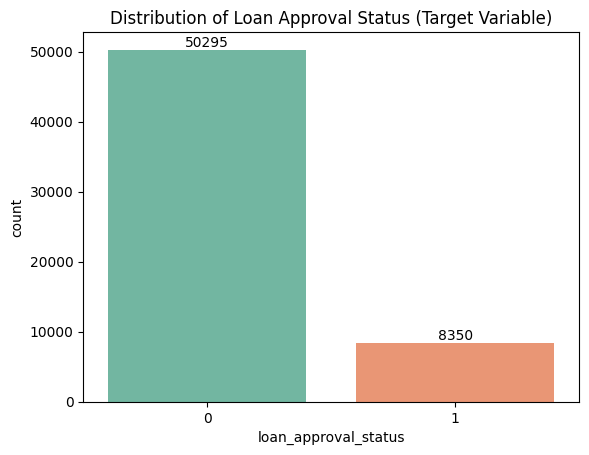

In [ ]:
# Import BarContainer from matplotlib to label bars
from matplotlib.container import BarContainer

# Create a count plot for the loan approval status
ax = sns.countplot(x='loan_approval_status', data=df, hue='loan_approval_status', palette='Set2', legend=False)

# Set the title for the plot
plt.title('Distribution of Loan Approval Status (Target Variable)')

# Iterate through the bar containers to add labels
for container in ax.containers:
    # Check if the container is an instance of BarContainer
    if isinstance(container, BarContainer):
        # Label each bar with its count
        ax.bar_label(container)

# Display the plot
plt.show()

## Cleaning Outliers

In [ ]:
# Print the maximum age before filtering
print("Max age BEFORE fix:", df['age'].max())
# Print the maximum employment length before filtering
print("Max employment length BEFORE fix:", df['emplyment_length'].max())

# Filter the dataframe to keep only rows where age is less than or equal to 100
df = df[df['age'] <= 100]
# Filter the dataframe to keep only rows where employment length is less than or equal to 60
df = df[df['emplyment_length'] <= 60]

# Print the maximum age after filtering
print("Max age AFTER fix:", df['age'].max())
# Print the maximum employment length after filtering
print("Max employment length AFTER fix:", df['emplyment_length'].max())

Max age BEFORE fix: 123.0
Max employment length BEFORE fix: 150
Max age AFTER fix: 84.0
Max employment length AFTER fix: 41


## Handling Negative Values & Imputation

In [ ]:
# Print the minimum interest rate before applying the absolute function
print("Min interest rate BEFORE fix:", df['loan_interest_rate'].min())
# Print counts of missing values for specific columns before imputation
print("\nMissing values BEFORE fix:\n", df[['age', 'loan_interest_rate', 'payment_default_on_file']].isnull().sum())

# Convert negative loan interest rates to their absolute positive values
df['loan_interest_rate'] = df['loan_interest_rate'].abs()

# Remove rows with negative max allowed loan amounts as they are erroneous
df = df[df['max_allowed_loan'] >= 0]

# FIX ADDED HERE: Replace 0s in max_allowed_loan with the client's actual loan_amount
df.loc[(df['loan_approval_status'] == 1) & (df['max_allowed_loan'] == 0), 'max_allowed_loan'] = df['loan_amount']

# Fill missing age values with the median of the column
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing interest rate values with the mean of the column
df['loan_interest_rate'] = df['loan_interest_rate'].fillna(df['loan_interest_rate'].mean())

# Fill missing categorical defaults with the most frequent value (mode)
df['payment_default_on_file'] = df['payment_default_on_file'].fillna(df['payment_default_on_file'].mode()[0])

# Print the minimum interest rate after the fix
print("\nMin interest rate AFTER fix:", df['loan_interest_rate'].min())
# Print counts of missing values for specific columns after imputation
print("\nMissing values AFTER fix:\n", df[['age', 'loan_interest_rate', 'payment_default_on_file']].isnull().sum())

Min interest rate BEFORE fix: -11.14

Missing values BEFORE fix:
 age                         0
loan_interest_rate         11
payment_default_on_file     5
dtype: int64

Min interest rate AFTER fix: 5.42

Missing values AFTER fix:
 age                        0
loan_interest_rate         0
payment_default_on_file    0
dtype: int64


## Data Subset Creation

In [ ]:
# Drop the unique ID column to create the modeling base dataframe
df_model = df.drop(columns=['id'])
# Create a subset for classification by dropping the regression target
subset_a_classification = df_model.drop(columns=['max_allowed_loan'])
# Create a subset for regression containing only rows with approved status
subset_b_regression = df_model[df_model['loan_approval_status'] == 1]

# Save the cleaned datasets as CSV files
subset_a_classification.to_csv('cleaned_classification_data.csv', index=False)
# Save the regression dataset to a CSV file
subset_b_regression.to_csv('cleaned_regression_data.csv', index=False)

# Print the dimensions of the regression subset
print("\nRegression Subset Shape:", subset_b_regression.shape)
# Print the feature names of the regression subset
print("Regression Subset Features:", subset_b_regression.columns.tolist())


Regression Subset Shape: (8348, 12)
Regression Subset Features: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']
